# Did Removing Free Allowances Speed Up Decarbonization in the EU ETS Power Sector?

## 1. Data pull

Fetch the EEA EU ETS bulk file (`eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00`) directly from the EEA datashare link and read it in memory. Nothing is saved to disk.

Note: the zip contains the data as an Excel workbook (`ETS_Database_September_2026.xlsx`), not a CSV.

In [1]:
import io
import zipfile

import pandas as pd
import requests

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)

URL = "https://sdi.eea.europa.eu/datashare/s/aZ7Ti5HkRGEbF62/download"

resp = requests.get(URL, timeout=120)
resp.raise_for_status()
zf = zipfile.ZipFile(io.BytesIO(resp.content))

print(f"Downloaded {len(resp.content):,} bytes")
for info in zf.infolist():
    print(f"{info.file_size:>12,}  {info.filename}")

Downloaded 8,208,395 bytes
           0  eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00/
   2,165,723  eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00/ETC-CM EU-ETS data quality September 2026.pdf
   3,597,611  eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00/ETS_Database_September_2026.xlsx
   2,029,162  eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00/EU Emission Trading System data viewer Background note (september 2026).pdf
     356,651  eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00/EU-ETS-sep-2026.jpg
      55,605  eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00/European_Union_Emissions_Trading_System_EU_ETS_data_from_the_Union_Reg_metadata_9eee3fc9-3060-4e3f-bc8d-e22e7c3f6bda.xml
       1,651  eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00/README.md


In [2]:
data_file = next(n for n in zf.namelist() if n.lower().endswith(".xlsx"))

# main_activity_code mixes plain codes ("20") with ranges ("20-99"), so keep it as text
df = pd.read_excel(io.BytesIO(zf.read(data_file)), dtype={"main_activity_code": str})

print(data_file)
print(df.shape)
df.dtypes

eea_t_eu-emission-trading-scheme_p_2005-2025_v03_r00/ETS_Database_September_2026.xlsx
(90325, 9)


version                  int64
country_code               str
main_activity_code         str
active_installation        str
citl_information           str
year                    object
size                       str
value                  float64
unit                       str
dtype: object

## 2. Inspect raw values (no filtering yet)

In [3]:
for col in ["size", "citl_information", "active_installation"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string())
    print()

--- size ---
size
All sizes    90325

--- citl_information ---
citl_information
1. Total allocated allowances (EUA or EUAA)                                     13422
1.1 Freely allocated allowances                                                 12944
1.1.1 Free allocation to existing entities (Art. 10a(1))                        12889
2. Verified emissions                                                           11151
2.1 EU-ETS Verified Emission                                                    11151
4. Total surrendered units                                                      10907
4.1 Surrendered EU allowances (EUAs and EUAAs)                                   7997
1.1.2 Free allocation from the new entrants reserve (Art. 10a(7))                2190
1.3 Allowances auctioned or sold (EUAs and EUAAs)                                1675
4.2 Surrendered certified emission reductions (CERs)                             1627
4.3 Surrendered emission reduction units (ERUs)             

In [4]:
df.head(10)

,version,country_code,main_activity_code,active_installation,citl_information,year,size,value,unit
0,82,AT,10,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,0.0,units
1,82,AT,20,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,14362552.0,units
2,82,AT,20-99,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,32412654.0,units
3,82,AT,21,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,2720740.0,units
4,82,AT,21-99,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,18050102.0,units
5,82,AT,22,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,1330079.0,units
6,82,AT,24,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,6869261.0,units
7,82,AT,29,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,2755179.0,units
8,82,AT,30,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,1320288.0,units
9,82,AT,31,all entities,1. Total allocated allowances (EUA or EUAA),2005,All sizes,215476.0,units


## 3. Cleaning

### 3.1 Activity-code lookup

The plan's translation table (`Translation of activity codes May 2019.xlsx`) is no longer downloadable: the EEA catalogue returns *"Metadata resource ... not found"*. The same code list is printed as Table 6-1 of the background note PDF included in the zip, so it's transcribed here. The aggregate rows `20-99` (all stationary installations) and `21-99` (all industrial installations) are sums of the individual codes.

In [5]:
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

ACTIVITY = {
    "10": "Aviation", "20": "Combustion of fuels", "21": "Refining of mineral oil",
    "22": "Production of coke", "23": "Metal ore roasting or sintering",
    "24": "Production of pig iron or steel", "25": "Production or processing of ferrous metals",
    "26": "Production of primary aluminium", "27": "Production of secondary aluminium",
    "28": "Production or processing of non-ferrous metals", "29": "Production of cement clinker",
    "30": "Production of lime, or calcination of dolomite/magnesite", "31": "Manufacture of glass",
    "32": "Manufacture of ceramics", "33": "Manufacture of mineral wool",
    "34": "Production or processing of gypsum or plasterboard", "35": "Production of pulp",
    "36": "Production of paper or cardboard", "37": "Production of carbon black",
    "38": "Production of nitric acid", "39": "Production of adipic acid",
    "40": "Production of glyoxal and glyoxylic acid", "41": "Production of ammonia",
    "42": "Production of bulk chemicals", "43": "Production of hydrogen and synthesis gas",
    "44": "Production of soda ash and sodium bicarbonate",
    "45": "Capture of greenhouse gases (Directive 2009/31/EC)",
    "46": "Transport of greenhouse gases (Directive 2009/31/EC)",
    "50": "Maritime operators", "99": "Other activity opted-in under Art. 24",
}
AGGREGATE_CODES = {"20-99", "21-99"}

unknown = set(df["main_activity_code"]) - set(ACTIVITY) - AGGREGATE_CODES
assert not unknown, f"Codes missing from lookup: {unknown}"

### 3.2 Drop single-valued columns (plan step 3)

In [6]:
for col in ["size", "active_installation", "version"]:
    assert df[col].nunique() == 1, f"{col} now has several values: {df[col].unique()}"

ets = df.drop(columns=["size", "active_installation", "version"])
ets.shape

(90325, 6)

### 3.3 Clean `year` (plan step 4)

Drop the trading-period total rows, convert to integer and keep 2005–2025 (2026–2030 hold only forward allocation figures).

In [7]:
is_year = pd.to_numeric(ets["year"], errors="coerce").notna()
print("Dropping non-year rows:", ets.loc[~is_year, "year"].value_counts().to_dict())

ets = ets[is_year].copy()
ets["year"] = ets["year"].astype(int)
ets = ets[ets["year"].between(2005, 2025)]
print(ets["year"].min(), "-", ets["year"].max(), ets.shape)

Dropping non-year rows: {'Total 4th trading period (21-30)': 4245, 'Total 3rd trading period (13-20)': 4005, 'Total 2nd trading period (08-12)': 3835, 'Total 1st trading period (05-07)': 2364}
2005 - 2025 (69879, 6)


### 3.4 Choose the metrics (plan step 5)

Two checks before filtering:
- `2. Verified emissions` and `2.1 EU-ETS Verified Emission` differ **only for aviation (code 10), 2020–2025**. They are identical for every stationary installation, so the choice doesn't matter once aviation is dropped. `2.` is used.
- `2.1b` (gap-filled emissions) exists only for 2025. The size of the gap-fill is shown below. The main series uses the reported figures for every year so the series is consistent, and 2025 is treated as provisional.

`1.2` (free-allocation corrections) and `3.` (scope estimates) are left out of the main series. Item `3.` is only published for the all-stationary total (`20-99`), 2005–2020, so it can't be split into power vs. industry anyway.

In [8]:
keys = ["country_code", "main_activity_code", "year"]
ve = ets[ets["citl_information"] == "2. Verified emissions"].set_index(keys)["value"]
ve21 = ets[ets["citl_information"] == "2.1 EU-ETS Verified Emission"].set_index(keys)["value"]
diff = (ve - ve21.reindex(ve.index)).loc[lambda s: s != 0]
print("Codes where 2. and 2.1 differ:", diff.index.get_level_values("main_activity_code").unique().tolist())
assert set(diff.index.get_level_values("main_activity_code")) <= {"10"}

gap = ets[(ets["citl_information"].str.startswith("2.1c")) & (ets["main_activity_code"] == "20-99")]["value"].sum()
reported = ve.xs(("20-99", 2025), level=["main_activity_code", "year"]).sum()
print(f"2025 gap-fill increment, all stationary, all countries: {gap/1e6:.1f} Mt "
      f"({gap/reported:.1%} of reported 2025 emissions)")

METRICS = {"2. Verified emissions": "emissions", "1.1 Freely allocated allowances": "free_alloc"}
ets = ets[ets["citl_information"].isin(METRICS)].copy()
ets["metric"] = ets["citl_information"].map(METRICS)
ets["metric"].value_counts()

Codes where 2. and 2.1 differ: ['10']
2025 gap-fill increment, all stationary, all countries: 6.4 Mt (0.6% of reported 2025 emissions)


metric
emissions     9339
free_alloc    9203
Name: count, dtype: int64

### 3.5 Activity filters and sector groups (plan steps 7–9)

- Drop the aggregate codes `20-99` and `21-99` (they would double count).
- Drop aviation (`10`) and maritime (`50`), keeping stationary installations only.
- **Power** = code `20`, combustion of fuels. This is the best proxy for power and heat the data offers. It also includes combustion units at industrial sites, so it's not a perfect match.
- **Industry** = codes `21`–`44`.
- Also dropped: `45`/`46` (CO2 capture/transport, essentially zero emissions) and `99` (opt-ins). Code 99 is a mixed bag that EEA itself says is "rarely clear", e.g. Sweden's small district-heating plants.

**Scope change in 2013.** Phase 3 brought new activities into the ETS (aluminium, non-ferrous metals, ammonia, nitric acid, bulk chemicals, hydrogen, etc.), so measured industry emissions jump in 2013 even though nothing really grew. For a robustness check, `constant_scope` marks the activities covered since 2005 (refining, coke, metal ore, iron & steel, cement, lime, glass, ceramics, pulp, paper).

In [9]:
POWER = {"20"}
INDUSTRY = {str(c) for c in range(21, 45)}
CONSTANT_SCOPE = {"21", "22", "23", "24", "29", "30", "31", "32", "35", "36"}

dropped = ets[~ets["main_activity_code"].isin(POWER | INDUSTRY)]
print("Dropped codes (emissions, 2025, all countries, Mt):")
print((dropped[(dropped["metric"] == "emissions") & (dropped["year"] == 2025)]
       .groupby("main_activity_code")["value"].sum() / 1e6).round(1).to_string())

ets = ets[ets["main_activity_code"].isin(POWER | INDUSTRY)].copy()
ets["group"] = np.where(ets["main_activity_code"].isin(POWER), "Power", "Industry")
ets["constant_scope"] = ets["main_activity_code"].isin(POWER | CONSTANT_SCOPE)

Dropped codes (emissions, 2025, all countries, Mt):
main_activity_code
10         59.3
20-99    1011.4
21-99     432.8
45          0.0
50         84.0
99          0.7


### 3.6 Countries (plan step 10)

- Drop the non-country entries (funds and auction programmes).
- Keep EU-27 member states only. That excludes `GB` (left the EU ETS after 2020), `XI` (Northern Ireland) and the EEA-EFTA states `IS`, `LI`, `NO`.
- Keep only countries with verified emissions in every year 2005–2025, so the panel is balanced.

In [10]:
EU27 = ["AT", "BE", "BG", "CY", "CZ", "DE", "DK", "EE", "ES", "FI", "FR", "GR", "HR", "HU",
        "IE", "IT", "LT", "LU", "LV", "MT", "NL", "PL", "PT", "RO", "SE", "SI", "SK"]
print("Dropping non-EU / non-country entries:", sorted(set(ets["country_code"]) - set(EU27)))
ets = ets[ets["country_code"].isin(EU27)]

years_reported = ets[ets["metric"] == "emissions"].groupby("country_code")["year"].agg(["min", "max", "nunique"])
incomplete = years_reported[years_reported["nunique"] < 21]
print("\nDropping countries without all 21 years:")
print(incomplete.to_string())

COUNTRIES = sorted(set(years_reported.index) - set(incomplete.index))
ets = ets[ets["country_code"].isin(COUNTRIES)]
print(f"\nKeeping {len(COUNTRIES)} countries:", " ".join(COUNTRIES))

Dropping non-EU / non-country entries:

 ['GB', 'IS', 'LI', 'NO', 'XI']

Dropping countries without all 21 years:
               min   max  nunique
country_code                     
BG            2007  2025       19
HR            2013  2025       13
RO            2007  2025       19

Keeping 24 countries: AT BE CY CZ DE DK EE ES FI FR GR HU IE IT LT LU LV MT NL PL PT SE SI SK


### 3.7 Pivot, unit checks and gaps (plan steps 11, 12, 16)

In [11]:
units = ets.groupby("metric")["unit"].unique()
print(units.to_string())
assert list(units["emissions"]) == ["tonne of CO2 equ."]
assert list(units["free_alloc"]) == ["units"]  # 1 allowance = 1 tCO2e

panel = (ets.pivot_table(index=["country_code", "main_activity_code", "group", "constant_scope", "year"],
                         columns="metric", values="value", aggfunc="sum")
            .reset_index())
panel.columns.name = None
print("\nMissing values after pivot:")
print(panel[["emissions", "free_alloc"]].isna().sum().to_string())
panel.head()

metric
emissions     [tonne of CO2 equ.]
free_alloc                [units]



Missing values after pivot:
emissions     47
free_alloc    55


,country_code,main_activity_code,group,constant_scope,year,emissions,free_alloc
0,AT,20,Power,True,2005,16539659.0,14362552.0
1,AT,20,Power,True,2006,15275065.0,14362552.0
2,AT,20,Power,True,2007,14124646.0,14442475.0
3,AT,20,Power,True,2008,14572511.0,12700742.0
4,AT,20,Power,True,2009,12767555.0,14324983.0


In [12]:
# Which cells lack free allocation, and how much do they emit?
no_fa = panel[panel["free_alloc"].isna()]
print(f"{len(no_fa)} rows with emissions but no free-allocation record; "
      f"{no_fa['emissions'].sum() / panel['emissions'].sum():.2%} of panel emissions")
print(no_fa.groupby("group")["emissions"].sum().div(1e6).round(1).to_string())

no_ve = panel[panel["emissions"].isna()]
print(f"\n{len(no_ve)} rows with free allocation but no emissions record "
      f"({no_ve['free_alloc'].sum() / panel['free_alloc'].sum():.2%} of panel free allocation)")

55 rows with emissions but no free-allocation record; 0.17% of panel emissions
group
Industry     5.1
Power       47.2

47 rows with free allocation but no emissions record (0.02% of panel free allocation)


In [13]:
# No record = nothing reported for that cell; treat as zero when summing
panel[["emissions", "free_alloc"]] = panel[["emissions", "free_alloc"]].fillna(0)

# Gaps at the country x group level (plan step 16)
cg = panel.groupby(["country_code", "group", "year"])["emissions"].sum().unstack("year")
zero_cells = (cg == 0).sum(axis=1).loc[lambda s: s > 0]
print("Country x group series with zero-emission years:")
print(zero_cells.to_string() if len(zero_cells) else "none")

Country x group series with zero-emission years:
none


### 3.8 Aggregate, index and free-allocation share (plan steps 13–15)

In [14]:
def aggregate(p, by):
    out = p.groupby(by, as_index=False)[["emissions", "free_alloc"]].sum()
    out["free_share"] = out["free_alloc"] / out["emissions"]
    return out

def add_index(d):
    d["index_2005"] = 100 * d["emissions"] / d.groupby("group")["emissions"].transform("first")
    return d

eu = add_index(aggregate(panel, ["group", "year"]))
eu_cs = add_index(aggregate(panel[panel["constant_scope"]], ["group", "year"]))
country = aggregate(panel, ["country_code", "group", "year"])

summary = eu.pivot(index="year", columns="group", values=["emissions", "index_2005", "free_share"])
summary["emissions"] = summary["emissions"] / 1e6
summary.round(2)

emissions          index_2005         free_share      
group  Industry    Power   Industry   Power   Industry Power
year                                                        
2005     522.24  1248.81     100.00  100.00       1.14  1.03
2006     531.31  1252.85     101.74  100.32       1.12  1.01
2007     535.36  1263.55     102.51  101.18       1.11  1.00
2008     534.76  1197.78     102.40   95.91       1.16  0.84
2009     439.55  1107.34      84.17   88.67       1.43  0.91
2010     466.37  1134.34      89.30   90.83       1.36  0.90
2011     461.54  1110.91      88.38   88.96       1.37  0.93
2012     438.79  1094.97      84.02   87.68       1.45  0.97
2013     498.53  1073.09      95.46   85.93       1.13  0.28
2014     500.44  1002.62      95.83   80.29       1.08  0.26
2015     500.33  1011.38      95.81   80.99       1.05  0.22
2016     500.93   993.26      95.92   79.54       1.04  0.19
2017     506.27   999.60      96.94   80.04       1.00  0.16
2018     503.47   944.85      96.41   75.66       0.99  0.15
2019     491.84   819.57      94.18   65.63       1.00  0.16
2020     454.82   705.88      87.09   56.52       1.05  0.14
2021     479.78   760.38      91.87   60.89       0.90  0.10
2022     451.31   765.13      86.42   61.27       0.96  0.09
2023     414.83   603.82      79.43   48.35       1.04  0.11
2024     413.17   547.81      79.12   43.87       0.97  0.11
2025     402.60   537.34      77.09   43.03       0.96  0.11

## 4. Charts

Power is blue and industry is orange in both charts. The 2013 policy change is marked with a vertical rule.

In [15]:
COLORS = {"Power": "#2a78d6", "Industry": "#eb6834"}
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"

def style(ax, title, ylabel):
    ax.set_title(title, loc="left", fontsize=12, color=INK, pad=12)
    ax.set_ylabel(ylabel, color=MUTED)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ["top", "right", "left"]:
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(MUTED)
    ax.tick_params(colors=MUTED, length=0)
    ax.set_xticks(range(2005, 2026, 4))
    ax.axvline(2012.5, color=MUTED, linewidth=1, linestyle=":")
    ax.text(2012.6, ax.get_ylim()[1], " Phase 3: power loses\n free allocation", va="top",
            fontsize=8.5, color=MUTED)

def label_end(ax, x, y, text, color):
    ax.annotate(text, (x, y), xytext=(6, 0), textcoords="offset points", va="center",
                fontsize=9.5, color=INK)
    ax.plot([x], [y], "o", color=color, markersize=6)

**Chart 1: the treatment.** Free allocation as a share of verified emissions.

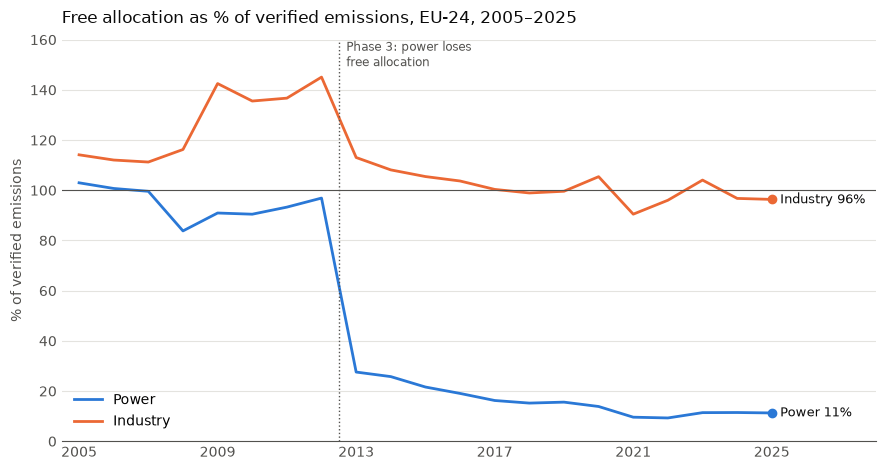

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for g in ["Power", "Industry"]:
    d = eu[eu["group"] == g]
    ax.plot(d["year"], 100 * d["free_share"], color=COLORS[g], linewidth=2, label=g)
    last = 100 * d["free_share"].iloc[-1]
    label_end(ax, 2025, last, f"{g} {last:.0f}%", COLORS[g])
ax.set_ylim(0, 160)
ax.set_xlim(2004.5, 2028)
style(ax, f"Free allocation as % of verified emissions, EU-{len(COUNTRIES)}, 2005–2025", "% of verified emissions")
ax.axhline(100, color=MUTED, linewidth=0.8)
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

**Chart 2: the result.** Verified emissions indexed to 2005 = 100. The dashed orange line is industry restricted to activities covered since 2005, which removes the 2013 scope jump.

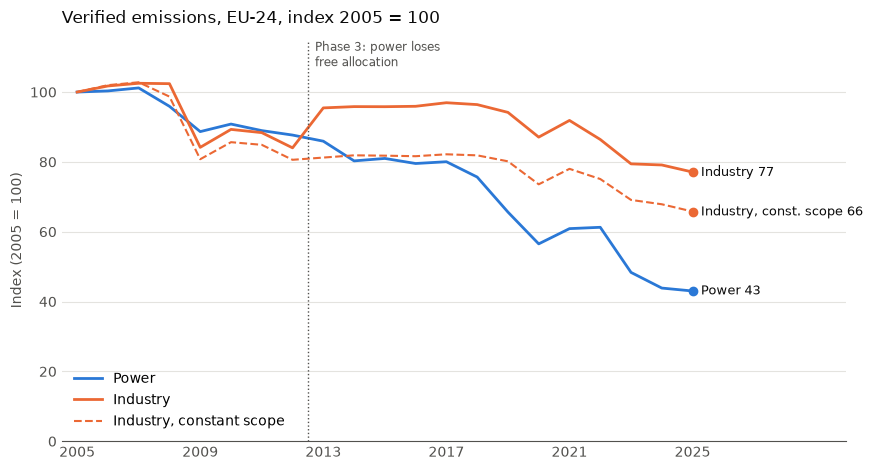

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for g in ["Power", "Industry"]:
    d = eu[eu["group"] == g]
    ax.plot(d["year"], d["index_2005"], color=COLORS[g], linewidth=2, label=g)
    label_end(ax, 2025, d["index_2005"].iloc[-1], f"{g} {d['index_2005'].iloc[-1]:.0f}", COLORS[g])
d = eu_cs[eu_cs["group"] == "Industry"]
ax.plot(d["year"], d["index_2005"], color=COLORS["Industry"], linewidth=1.5, linestyle="--",
        label="Industry, constant scope")
label_end(ax, 2025, d["index_2005"].iloc[-1], f"Industry, const. scope {d['index_2005'].iloc[-1]:.0f}",
          COLORS["Industry"])
ax.set_ylim(0, 115)
ax.set_xlim(2004.5, 2030)
style(ax, f"Verified emissions, EU-{len(COUNTRIES)}, index 2005 = 100", "Index (2005 = 100)")
ax.legend(frameon=False, loc="lower left")
plt.tight_layout()
plt.show()

## 5. Test: did power's emissions trend change more than industry's after 2013?

The plan's model is `log(emissions) ~ year + sector + year:sector` with a post-2013 indicator. Written out in full:

$$\log E_{st} = \beta_0 + \beta_1 t + \beta_2\,\text{post}_t + \beta_3\, t\cdot\text{post}_t + \text{Power}_s\,(\gamma_0 + \gamma_1 t + \gamma_2\,\text{post}_t + \gamma_3\, t\cdot\text{post}_t) + \varepsilon_{st}$$

with $t$ = year − 2013 and post = 1 from 2013. Each sector gets its own level shift in 2013 ($\beta_2$, $\gamma_2$), so the industry scope jump doesn't register as a trend change. **The test is $\gamma_3$ (`power:t:post`).** It measures how much more power's log-trend changed after 2013 than industry's did. If the expectation holds, $\gamma_3 < 0$.

Standard errors are Newey-West (HAC, 2 lags) because these are annual time series. There are only 42 observations, so p-values are approximate.

First, the simple version: the average annual % change in emissions for each sector and period.

In [18]:
def prep(d):
    d = d.copy()
    d["t"] = d["year"] - 2013
    d["post"] = (d["year"] >= 2013).astype(int)
    d["power"] = (d["group"] == "Power").astype(int)
    return d

def annual_trend(d):
    b = smf.ols("np.log(emissions) ~ year", data=d).fit().params["year"]
    return 100 * (np.exp(b) - 1)

trends = (prep(eu).groupby(["group", "post"])[["year", "emissions"]].apply(annual_trend)
            .unstack("post").rename(columns={0: "2005–2012", 1: "2013–2025"}))
trends["change"] = trends["2013–2025"] - trends["2005–2012"]
print("Average annual % change in verified emissions")
trends.round(2)

Average annual % change in verified emissions


post,2005–2012,2013–2025,change
group,,,
Industry,-2.97,-1.91,1.06
Power,-2.26,-5.79,-3.53


In [19]:
FORMULA = "np.log(emissions) ~ power * (t + post + t:post)"
hac = dict(cov_type="HAC", cov_kwds={"maxlags": 2})

main = smf.ols(FORMULA, data=prep(eu)).fit(**hac)
print(main.summary().tables[1])
g3 = main.params["power:t:post"]
print(f"\npower:t:post = {g3:.4f}  ->  power's post-2013 trend changed by {100 * g3:.2f} log points/yr "
      f"more than industry's (p = {main.pvalues['power:t:post']:.3f})")

                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       19.8733      0.016   1273.454      0.000      19.843      19.904
power            0.9077      0.019     47.944      0.000       0.871       0.945
t               -0.0301      0.004     -7.482      0.000      -0.038      -0.022
post             0.2088      0.031      6.686      0.000       0.148       0.270
t:post           0.0109      0.005      1.998      0.046       0.000       0.021
power:t          0.0072      0.005      1.575      0.115      -0.002       0.016
power:post      -0.1237      0.059     -2.096      0.036      -0.239      -0.008
power:t:post    -0.0476      0.008     -5.815      0.000      -0.064      -0.032

power:t:post = -0.0476  ->  power's post-2013 trend changed by -4.76 log points/yr more than industry's (p = 0.000)


## 6. Robustness

1. **Constant-scope industry**: the same model with industry limited to activities covered since 2005.
2. **Excluding 2025**: 2025 is provisional (gap-filled latest year).
3. **Country panel**: country × sector series, with a fixed effect for each country × sector and standard errors clustered by country. Each country counts equally here, so a few big emitters can't drive the result. Zero-emission series are dropped (log undefined).
4. **Leave-one-country-out**: re-run the EU-level model once per country, dropping that country each time (e.g. Germany or Poland).

In [20]:
def key_coef(fit, name="power:t:post"):
    ci = fit.conf_int().loc[name]
    return pd.Series({"coef": fit.params[name], "se": fit.bse[name], "p": fit.pvalues[name],
                      "ci_low": ci[0], "ci_high": ci[1], "n": int(fit.nobs)})

results = {
    "Main (all industry)": key_coef(main),
    "Constant-scope industry": key_coef(smf.ols(FORMULA, data=prep(eu_cs)).fit(**hac)),
    "Excluding 2025": key_coef(smf.ols(FORMULA, data=prep(eu[eu["year"] < 2025])).fit(**hac)),
}

cp = prep(country[country["emissions"] > 0])
cp["unit"] = cp["country_code"] + "_" + cp["group"]
full_units = cp.groupby("unit")["year"].transform("nunique") == 21
print("Country x sector series dropped for missing/zero years:", sorted(cp.loc[~full_units, "unit"].unique()))
absent = sorted({f"{c}_{g}" for c in COUNTRIES for g in ["Power", "Industry"]} - set(cp["unit"]))
print("Country x sector series that don't exist at all (no installations):", absent)
cp = cp[full_units]
panel_fit = smf.ols("np.log(emissions) ~ C(unit) + t + post + t:post + power:t + power:post + power:t:post",
                    data=cp).fit(cov_type="cluster", cov_kwds={"groups": cp["country_code"]})
results["Country panel (FE, clustered by country)"] = key_coef(panel_fit)

pd.DataFrame(results).T.round(4)

Country x sector series dropped for missing/zero years: []
Country x sector series that don't exist at all (no installations): ['MT_Industry']


,coef,se,p,ci_low,ci_high,n
Main (all industry),-0.0476,0.0082,0.0,-0.0636,-0.0316,42.0
Constant-scope industry,-0.0562,0.0082,0.0,-0.0722,-0.0402,42.0
Excluding 2025,-0.0471,0.0087,0.0,-0.0641,-0.0301,40.0
"Country panel (FE, clustered by country)",-0.0624,0.0125,0.0,-0.0869,-0.0380,987.0


In [21]:
loo = {}
for c in COUNTRIES:
    d = aggregate(panel[panel["country_code"] != c], ["group", "year"])
    loo[c] = smf.ols(FORMULA, data=prep(d)).fit(**hac).params["power:t:post"]
loo = pd.Series(loo).sort_values()
print(f"Leave-one-out power:t:post: min {loo.min():.4f} (drop {loo.idxmin()}), "
      f"max {loo.max():.4f} (drop {loo.idxmax()}), main {g3:.4f}")
loo.round(4).to_frame("coef_without_country").T

Leave-one-out power:t:post: min -0.0511 (drop PL), max -0.0435 (drop GR), main -0.0476


,PL,IT,SK,BE,HU,LT,DE,LV,LU,CY,...,DK,SE,AT,IE,FI,CZ,PT,EE,ES,GR
coef_without_country,-0.0511,-0.0507,-0.0488,-0.0487,-0.0483,-0.0479,-0.0479,-0.0477,-0.0476,-0.0476,...,-0.0474,-0.0473,-0.0473,-0.0472,-0.0472,-0.0471,-0.0467,-0.0464,-0.046,-0.0435


## 7. Conclusion

**Did removing free allowances from the power sector lead to a steeper decline in emissions than in industry, which kept its free allocation? The data are consistent with yes.**

- **The treatment is real (Chart 1).** Free allocation to power (code 20) fell from 97% of emissions in 2012 to 28% in 2013 and about 11% by 2025. Industry stayed at roughly 100% throughout.
- **The outcome diverges (Chart 2).** From 2005 to 2012 the two sectors fell at similar rates (power −2.3%/yr, industry −3.0%/yr; industry even fell faster because the 2009 recession hit it harder). From 2013 to 2025, power fell −5.8%/yr while industry fell only −1.9%/yr. By 2025 power is at 43% of its 2005 level; industry is at 77%, or 66% on a constant-scope basis.
- **The test.** Power's log-trend steepened after 2013 by about 4.8 percentage points per year more than industry's (`power:t:post` = −0.048, 95% CI −0.064 to −0.032).
- **The result holds up.** It survives a constant-scope industry definition (−0.056), dropping provisional 2025 (−0.047), a country panel that weights all countries equally with country-clustered SEs (−0.062), and dropping any single country (range −0.051 without Poland to −0.044 without Greece). It isn't driven by Germany or Poland.

So the result **does not** match the "contradicting" scenario in the plan, where industry falls just as fast despite keeping free allowances.

### Caveats

- **Timing.** Power emissions were fairly flat from 2014 to 2017 and fell steeply from 2018 on. That coincides with the 2018 rise in EUA prices after the Market Stability Reserve reform, cheaper gas and renewables, and national coal exits, more than with the 2013 allocation change itself. No price data is used here, so this timing story is context, not something this notebook tests. The post-2013 linear trend averages over this. The evidence fits "full exposure to the carbon price mattered once the price was meaningful" better than "removing free allocation alone did it".
- **Correlational, not causal.** Other things changed for power after 2013: renewable deployment, gas–coal price swings, national coal phase-outs, and the 2020 COVID dip and 2022 energy crisis. Industry also faces different demand shocks. The two sectors are not a clean treatment/control pair.
- **"Power" is a proxy.** Code 20 (combustion of fuels) includes combustion units at industrial sites, which still receive some free allocation for heat. That is part of why power's free share is ~11%, not 0%.
- **Scope changes.** Phase 3 added activities to industry in 2013 (+60 Mt). The model's sector-specific 2013 level shifts and the constant-scope check handle this, but EEA's own scope estimates (item 3) can't be split by sector.
- **Data notes.** The plan's activity-code translation file is no longer online, so codes come from Table 6-1 of the EEA background note. Bulgaria and Romania (joined 2007) and Croatia (2013) are excluded to keep the panel balanced (EU-24). Malta has no industrial installations. 2025 is partly gap-filled (+0.6% EU-wide). Only 42 annual observations go into the main regression, so the p-values are approximate.